<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_n_dog_modeling_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [3]:
# Modeling

# 1st Conv
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', 
                              kernel_regularizer=tf.keras.regularizers.l2(0.2), 
                              padding = 'same', input_shape=(224, 224, 1)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(2))
# 2nc Conv
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', 
                              kernel_regularizer=tf.keras.regularizers.l2(0.02), 
                              padding = 'same'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(2))
# 3rd Conv
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', 
                              kernel_regularizer=tf.keras.regularizers.l2(0.02), 
                              padding = 'same'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.MaxPooling2D(2))
# Dense
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation='sigmoid'))

Batch Normalization reference
https://eehoeskrap.tistory.com/430

In [4]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     256       
 hNormalization)                                                 
                                                        

In [5]:
train_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled'
train_path_list = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_set_part_path = os.path.join(dirname, filename)
            train_path_list.append(train_set_part_path)

train_path_list.sort()

In [6]:
train_target_path = '/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part'
train_target_path_list = []

for dirname, _, filenames in os.walk(train_target_path):
    for filename in filenames:
        if(filename.endswith('npy')):
            train_target_part_path = os.path.join(dirname, filename)
            train_target_path_list.append(train_target_part_path)
        
train_target_path_list.sort()

In [7]:
# Load Dataset

train_set = []
train_target = []

for x_path, y_path in zip(train_path_list, train_target_path_list):
    a = np.load(x_path, allow_pickle=True)
    b = np.load(y_path, allow_pickle=True)

    print(len(a), len(b), sep=' ', end='\n')
    print(x_path, y_path)
    print(a.shape, b.shape)

    for x in a:
        train_set.append(x/255.0)
    for y in b:
        train_target.append(y)

    del a
    del b

train_set = np.array(train_set)
train_target = np.array(train_target)

2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_1.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_1.npy
(2000, 224, 224) (2000,)
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_10.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_10.npy
(2000, 224, 224) (2000,)
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_11.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_11.npy
(2000, 224, 224) (2000,)
2000 2000
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_12.npy /content/drive/MyDrive/cat_n_dog/data_scaled_numpy/train_target_part/train_target_12.npy
(2000, 224, 224) (2000,)
15 15
/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/training_set_scaled/train_scaled_13.npy /content/drive/MyDrive/cat_n_dog/data_scaled_

In [8]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics='accuracy')

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

learning_rate_reduction_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', patience = 2, verbose=1, factor=0.5, min_lr=0.00001
)

In [9]:
# train_set, validation_set 분리
x_train, x_val, y_train, y_val = train_test_split(
    train_set, train_target, test_size=0.1, random_state=42
)

In [11]:
# Training
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val),
               callbacks=[early_stopping_cb, learning_rate_reduction_cb], batch_size = 16)

Epoch 1/20
1351/1351 [==============================] - 468s 347ms/step - loss: 0.9503 - accuracy: 0.6341 - val_loss: 0.7055 - val_accuracy: 0.6524 - lr: 0.0010
Epoch 2/20
1351/1351 [==============================] - 465s 345ms/step - loss: 0.6541 - accuracy: 0.7006 - val_loss: 0.7240 - val_accuracy: 0.6149 - lr: 0.0010
Epoch 3/20
1351/1351 [==============================] - ETA: 0s - loss: 0.6310 - accuracy: 0.7171
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1351/1351 [==============================] - 460s 341ms/step - loss: 0.6310 - accuracy: 0.7171 - val_loss: 0.7540 - val_accuracy: 0.6524 - lr: 0.0010
Epoch 4/20
1351/1351 [==============================] - 462s 342ms/step - loss: 0.5572 - accuracy: 0.7584 - val_loss: 0.6114 - val_accuracy: 0.7223 - lr: 5.0000e-04
Epoch 5/20
1351/1351 [==============================] - 460s 340ms/step - loss: 0.5288 - accuracy: 0.7770 - val_loss: 0.6579 - val_accuracy: 0.6978 - lr: 5.0000e-04
Epoch 6/20
1351/1351 [==

In [12]:
def show_graph(history_):
    accuracy = history_.history['accuracy']
    val_accuracy = history_.history['val_accuracy']
    loss = history_.history['loss']
    val_loss = history_.history['val_loss']

    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 2))

    plt.subplot(121)
    plt.ylim(0, 1.1)
    plt.subplots_adjust(top=2)
    plt.plot(epochs, accuracy, 'ro', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Trainging and validation accuracy and loss')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy and Loss')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
              fancybox=True, shadow=True, ncol=5)
#     plt.legend(bbox_to_anchor=(1, -0.1))

    plt.subplot(122)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=5)
#     plt.legend(bbox_to_anchor=(1, 0))

    plt.show()

reference
https://chealin93.tistory.com/69

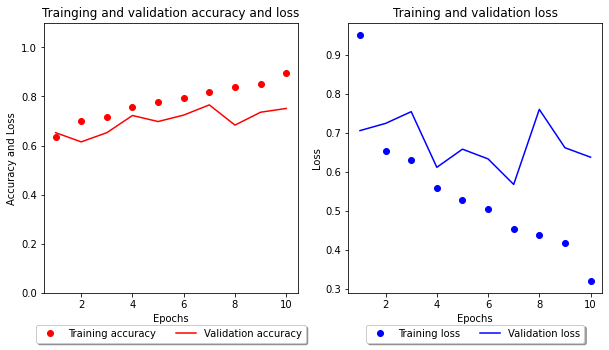

In [14]:
show_graph(history)

In [15]:
# Load Test Set

test_set = np.load('/content/drive/MyDrive/cat_n_dog/data_scaled_numpy/test_set_scaled/test_scaled.npy', allow_pickle=True)
test_target = np.load('/content/drive/MyDrive/cat_n_dog/data_numpy/test_target.npy', allow_pickle=True)

In [16]:
print(test_set.shape)

(2023, 224, 224)


In [17]:
test_set_scaled = test_set / 255.0

model.evaluate(test_set_scaled, test_target)

64/64 [==============================] - 5s 76ms/step - loss: 0.6041 - accuracy: 0.7647


[0.6041153073310852, 0.7647058963775635]

(1, 224, 224, 1)


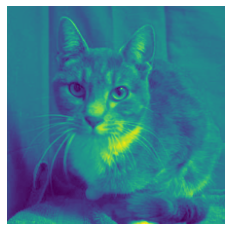

In [18]:
sample = test_set[58] / 255.0
sample = sample.reshape(1, 224, 224, 1)
print(sample.shape)
plt.imshow(test_set[58])
plt.axis('off')
plt.show()

In [19]:
def print_predict(sample_):
    result = model.predict(sample)
    result = result[0][0]
    

    print('RESULT: ', end='')
    if(result < 0.5):
        print('Cat')
    elif(result > 0.5):
        print('Dog')
    else:
        print('Can\'t know')

In [20]:
print_predict(sample)

1/1 [==============================] - 0s 162ms/step
RESULT: Cat
